
# Método de punto fijo

**Algoritmo 2.2 de Burden — Ejemplo 1**

Se resolverá la ecuación del ejemplo de la página 38:

$$
x^3+4x^2-10=0
$$



## 1. Fórmula

En la página 46, Burden muestra varias formas de escribir la ecuación como $x=g(x)$. Usaremos la opción (d):

$$
g(x)=\left(\frac{10}{4+x}\right)^{1/2}
$$

El valor inicial es $p_0=1.5$. En cada paso se calcula:

$$
p_n=g(p_{n-1})
$$

El proceso termina cuando la diferencia entre dos valores seguidos es menor que la tolerancia.



## 2. Importar la biblioteca

`math` permite calcular la raíz cuadrada y `matplotlib` se usará para hacer la gráfica.


In [1]:

import matplotlib.pyplot as plt



## 3. Definir las funciones

La función `f` representa la ecuación original. La función `g` se usa para obtener cada aproximación.


In [2]:

def f(x):
    return x**3 + 4*x**2 - 10

def g(x):
    return (10 / (4 + x))**(1/2)



## 4. Método de punto fijo

El ciclo `for` repite el cálculo. `abs` obtiene la diferencia positiva entre las aproximaciones. La lista guarda los resultados para mostrarlos al final.


In [3]:

def punto_fijo(p0, tol, nmax):
    datos = []

    for i in range(1, nmax + 1):
        p = g(p0)
        error = abs(p - p0)
        datos.append((i, p, f(p), error))

        if error < tol:
            return p, datos, True

        p0 = p

    return p, datos, False



## 5. Resolver el ejemplo

Se usa $p_0=1.5$, una tolerancia de $10^{-5}$ y un máximo de 100 iteraciones.


In [4]:

p0 = 1.5
tol = 1e-5
nmax = 100

raiz, datos, exito = punto_fijo(p0, tol, nmax)

print("Iteración      p_n             f(p_n)          Diferencia")
for i, p, valor_f, error in datos:
    print(f"{i:5d}      {p:.10f}     {valor_f:.3e}     {error:.3e}")

print()
if exito:
    print(f"Raíz aproximada: {raiz:.10f}")
    print(f"f(raíz) = {f(raiz):.3e}")
else:
    print("No se alcanzó la tolerancia en el número máximo de iteraciones.")


Iteración      p_n             f(p_n)          Diferencia
    1      1.3483997249     -2.756e-01     1.516e-01
    2      1.3673763720     3.548e-02     1.898e-02
    3      1.3649570154     -4.508e-03     2.419e-03
    4      1.3652647481     5.736e-04     3.077e-04
    5      1.3652255942     -7.298e-05     3.915e-05
    6      1.3652305757     9.285e-06     4.982e-06

Raíz aproximada: 1.3652305757
f(raíz) = 9.285e-06



## 6. Gráfica

La gráfica muestra la función original y la raíz aproximada.


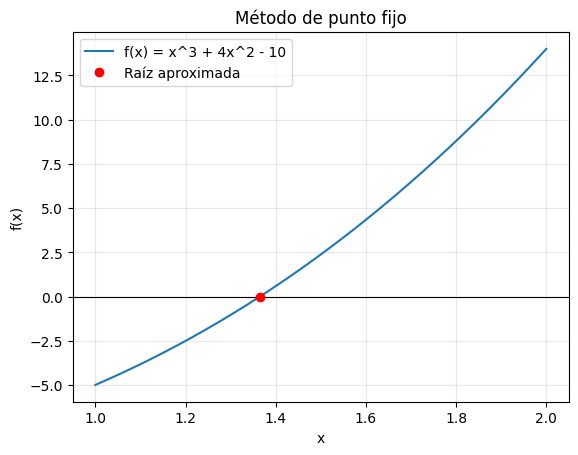

In [5]:

x = [1 + i * (1 / 299) for i in range(300)]
y = [f(valor) for valor in x]

plt.plot(x, y, label="f(x) = x^3 + 4x^2 - 10")
plt.axhline(0, color="black", linewidth=0.8)
plt.plot(raiz, f(raiz), "ro", label="Raíz aproximada")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Método de punto fijo")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()



## 7. Conclusión

Con la función $g(x)$ elegida y el valor inicial $p_0=1.5$, el método se acerca a la raíz positiva de la ecuación original.

$$
p\approx 1.36523
$$
